# Módulo 3: Limpieza y transformación de datos

## Selección de características:  Lasso Regression

#### Objetivo
* Conceptos
    * Explicar someramente qué es una regresión Lasso.
        * Tener claro que una regresión Lasso es una regresión lineal con una penalización. 
    * Usar la regresión Lasso para eliminación de features irrelevantes.
    
    
#### Actividad 1 guiada:
* Ejemplificar cómo funciona una regresión Lasso y cómo los coeficientes se ven afectados a distintos $\lambda$. 
    * Tomar el set precios de casas en Boston (`sklearn.datasets.load_boston`)


#### Actividad 2 autónoma:
* Tomar el set `actividad2b_7_1.csv`.
    * Este set fue un set preparado de manera sintética, toma eso en cuenta a la hora de responder tus preguntas de aplicación.
* Aplicar el código hecho, experimentar con varios lambdas y/o steps y responder:
    * Conceptos:
        * ¿En qué es diferente una regresión Lasso a una regresión lineal? 
        * ¿Cómo afecta el coeficiente $\lambda$ al momento de usar una regresión Lasso?
        * ¿Cómo podemos usar el algoritmo Lasso de la misma manera que una regresión lineal?
        * ¿Qué implica un coeficiente alto al momento de usar una regresión Lasso? 
    * Aplicación
        * ¿En qué punto de eliminación de variables cambia el error? 
        * ¿Qué te hace pensar que a partir de ese punto ya no se eliminan más features?
        * ¿Cuántos features remueves? Justifique tu respuesta.
        * Si de un punto a otro no cambia el error (o cambia muy poco), ¿te quedas con más o menos features? Justifica tu respuesta.


https://www.analyticsvidhya.com/blog/2017/06/a-comprehensive-guide-for-linear-ridge-and-lasso-regression/
https://medium.com/analytics-vidhya/math-behind-linear-ridge-and-lasso-regression-b9de216ebdf8    

### Least Absolute Shrinkage and Selection Regression: Lasso Regression


En general todos los algoritmos cuentan con algo denominado **función de costo** que no es otra cosa que la función a minimizar (por eso se denomina "costo"). 

Generalmente estas funciones representan una desviación / error que puede estar implícito a la hora obtener la estimación.

En la regresión lineal, el costo suele ser el de _mínimos cuadrados_. 

$$C = \frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y_i})^2$$

Que no es otra cosa que el error cuadrático medio entre las muestras reales y las estimaciones.

Lasso agrega un término conocido como _regularización L1_ quedando de la siguiente manera:

$$C = \frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y_i})^2 + \lambda \sum_{j=1}^J |w_j|$$

Lasso agrega una penalización con el valor absoluto de los coeficientes (lo que en la clase pasada llamamos $\beta$). 

Esto implica que los pesos, en caso de crecer mucho, van a incrementar el costo, por lo que nuestro algoritmo buscará en otra área su convergencia. 

Esta característica lleva a tener coeficientes pequeños (que no nos fijemos únicamente en una o dos variables) además de **encogimiento** (shrinkage) de coeficientes a cero, lo que equivale a una **selección de variables** implícita. 

Es importante resaltar que Lasso es un modelo de **regresión**, no así de clasificación.


#### Mediciones de error más  comunes en problemas de regresión

$$
\text{MAE}(y, \hat{y}) = \frac{1}{n} \sum_{i=0}^n \left|y_i - \hat{y_i} \right|
$$

$$
\text{MAPE}(y, \hat{y}) = \frac{1}{n}\sum_{i=0}^n \left|\frac{y_i-\hat{y_i}}{y_i}\right|
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error
import warnings
import os
import pickle
from pprint import pprint

warnings.filterwarnings("ignore")

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '.'

Tomemos un set con existencia previa en la librería `sklearn` sobre inmuebles en Boston. 

In [7]:

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
x = pd.DataFrame(np.hstack([raw_df.values[::2, :],
                               raw_df.values[1::2, :2]]))
y = raw_df.values[1::2, 2]

x.columns = [f'x{i}' for i in range(len(x.columns))]
predictors = x.columns
df = pd.DataFrame(x)
df['y'] = y
df

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


Generemos un modelo `Lasso` (sin _fittear_ aun)

In [12]:
lasso_model = Lasso(alpha=1, random_state=seed)

Tomemos sets de entrenamiento y prueba (para validación de nuestro modelo)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    df[predictors],
    df['y'],
    random_state=seed,
    test_size=0.2
)

train = pd.merge(x_train, y_train, left_index=True, right_index=True)
test = pd.merge(x_test, y_test, left_index=True, right_index=True)

Hagamos fit de nuestro modelo 

In [13]:
lasso_model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",28
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Analicemos los coeficientes que generó nuestro modelo. 

Recordar que por dentro sigue siendo una regresión de la forma:
    
$$
\hat{y} = \beta_0 + \beta_1x_1 + \dots \beta_nx_n
$$

Los coeficientes de esta regresión son entonces escogidos con la metodología descrita al inicio del notebook.

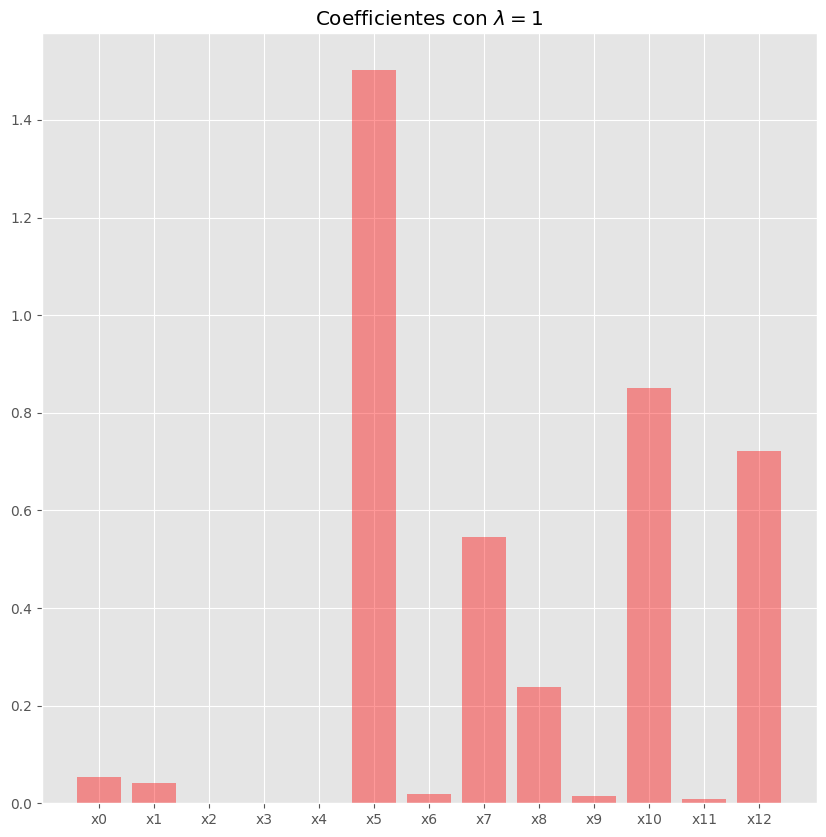

In [14]:
coefs = abs(lasso_model.coef_)
index = range(len(coefs))

fig, ax = plt.subplots(figsize=(10, 10))

ax.bar(index, coefs, color='red', alpha=0.4)

ax.set_xticks(index)
ax.set_xticklabels(predictors)

ax.set_title('Coefficientes con $\lambda=1$')
fig.show()

Vemos que solo algunos coeficientes sobrevivieron a este modelo, todos los demás fueron considerados irrelevantes. Veamos qué tan bueno fue el performance.

In [5]:
# Variables donde guardaremos resultados

# Los sets a los que mediré el error




    # Getting scores
    

    # Getting y_true
    

    # Getting MeanAE
    

    # Getting MedianAE
    

    # Getting MAPE
    




In [6]:
# Veamos errores


In [8]:


# Ploteando errores

# Plottear variable de respuesta


Hagamos a continuación una comparación de scores entre los sets de entrenamiento y test.

Recordar: 
    
* El modelo perfecto tendría las mismas conclusiones que la variable de respuesta: Scores muy altos en los inmuebles caros y scores muy bajos en los datos con precios de inmuebles no caros.

* Separamos en _train_ y _test_ para poder entrenar nuestro modelo y validar. Esperamos un performance muy bueno en el _train_ que debería de mantenerse en el _test_.
   
   

In [9]:
# Ejes

# Graficando respuesta real


# Graficando scores de entrenamiento



# Respuesta real de los no vistos por el modelo.


# Scores de test


# Títulos 


##### Conclusión parcial.
* El modelo es bastante bueno estimando en ambas poblaciones con un lambda ($\lambda$) de 1.0.
* Se eliminaron 3 features y hay otros que están cerca de eliminarse.


¿Cómo se vería una regresión lineal con todos los features? ¿Cómo cambia el performance al variar $\lambda$?


Generaremos un experimento en el cual veremos el cambio de performance y de variables seleccionadas a través de una serie de cambios de lambdas ($\lambda$).

In [10]:
# Generemos "steps" para Lasso


In [11]:
# Generando múltiples modelos

    # Entrenando

    
    # Storeando el modelo

    
    # Evaluando el modelo

    
    # Errores

    # Coeficients


Comparemos los errores y los coeficientes de cada corrida.

In [12]:
# Errors and coefficients


¿Dónde cambia más el error? ¿Cuál es el punto adecuado para seleccionar nuestro nivel de $\lambda$ adecuada? 

Definamos el cambio del error. El símil en términos de cálculo sería la aceleración y/o cambio del cambio.

Supongamos el precio de una papaya hoy está en 15 pesos pero el día de ayer estaba en 10 pesos. ¿Cuánto aumentó el precio? 

$$
\begin{equation}
    \begin{split}
        \text{cambio} &= \frac{\text{hoy} - \text{ayer}}
        {\text{ayer}} \\
        \text{cambio} &= \frac{\text{hoy}}{\text{ayer}} - \frac{\text{ayer}}{\text{ayer}}\\
        \text{cambio} &= \frac{\text{hoy}}{\text{ayer}} - 1 \\ 
        \text{cambio} &= \frac{15}{10} - 1\\
        \text{cambio} &= 0.50
    \end{split}
\end{equation}
$$

El precio de la papaya subió 50% de un día a otro. 


Usaremos esta misma lógica para calcular diferencial relativo del error en el caso del MAE, en el caso del MAPE solo sacaremos la diferencia entre los errores pues ya son porcentajes.

In [13]:
# Cambio MAPE


Agreguemos los errores a las gráficas.

In [14]:
# Errors and coefficients


# Leyendas




### Conclusiones actividad 1

